In [2]:
import pandas as pd

df = pd.read_csv('data/q3_retail_promotions.csv')

print("Shape:", df.shape)
df.head()

Shape: (1200, 9)


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

In [4]:
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Month end flag
df['is_month_end'] = df['transaction_date'].dt.day >= 25
df['is_month_end'] = df['is_month_end'].astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [5]:
df = df.sort_values('transaction_date')

In [6]:
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

In [7]:
X_train = train_df.drop(['items_sold'], axis=1)
y_train = train_df['items_sold']

X_test = test_df.drop(['items_sold'], axis=1)
y_test = test_df['items_sold']

In [8]:
print(train_df['transaction_date'].max())
print(test_df['transaction_date'].min())

2024-06-11 00:00:00
2024-06-12 00:00:00


In [9]:
cat_cols = ['promotion_type', 'location_type', 'store_size']

In [10]:
num_cols = [
    'competition_density',
    'year',
    'month',
    'day_of_week',
    'is_weekend',
    'is_festival',
    'is_month_end'
]

In [11]:
X_train = X_train.drop('transaction_date', axis=1)
X_test = X_test.drop('transaction_date', axis=1)

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [13]:
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['promotion_type', 'location_type', 'store_size']
Numerical: ['competition_density', 'year', 'month', 'day_of_week', 'is_weekend', 'is_festival', 'is_month_end']


In [14]:
print(X_train.columns)

Index(['store_id', 'store_size', 'location_type', 'promotion_type',
       'is_weekend', 'is_festival', 'competition_density', 'year', 'month',
       'day_of_week', 'is_month_end'],
      dtype='object')


In [15]:
print(preprocessor)

ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first'),
                                 ['promotion_type', 'location_type',
                                  'store_size']),
                                ('num', StandardScaler(),
                                 ['competition_density', 'year', 'month',
                                  'day_of_week', 'is_weekend', 'is_festival',
                                  'is_month_end'])])


In [16]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print(X_train_transformed.shape)
print(X_test_transformed.shape)

(960, 15)
(240, 15)


In [17]:
preprocessor.fit_transform(X_train)

array([[ 0.        ,  0.        ,  1.        , ...,  1.59041245,
        -0.3615827 , -0.50650222],
       [ 0.        ,  0.        ,  1.        , ...,  1.59041245,
         2.76561904, -0.50650222],
       [ 0.        ,  0.        ,  0.        , ...,  1.59041245,
        -0.3615827 , -0.50650222],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  1.59041245,
        -0.3615827 , -0.50650222],
       [ 0.        ,  0.        ,  1.        , ..., -0.62876771,
        -0.3615827 , -0.50650222],
       [ 0.        ,  0.        ,  0.        , ..., -0.62876771,
        -0.3615827 , -0.50650222]], shape=(960, 15))

In [18]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [21]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [22]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression - RMSE:", rmse_lr, "MAE:", mae_lr)
print("Random Forest - RMSE:", rmse_rf, "MAE:", mae_rf)

Linear Regression - RMSE: 27.12522339961421 MAE: 21.071451412620927
Random Forest - RMSE: 31.94980603265181 MAE: 25.639152777777777


The Linear Regression model outperforms the Random Forest model based on both RMSE and MAE metrics.

Linear Regression achieves a lower RMSE (27.12) and MAE (21.07) compared to Random Forest, which has higher error values. This indicates that Linear Regression provides more accurate predictions for this dataset.

This suggests that the relationship between the features and the target variable (items_sold) is relatively linear, allowing Linear Regression to model it more effectively than the more complex Random Forest model.

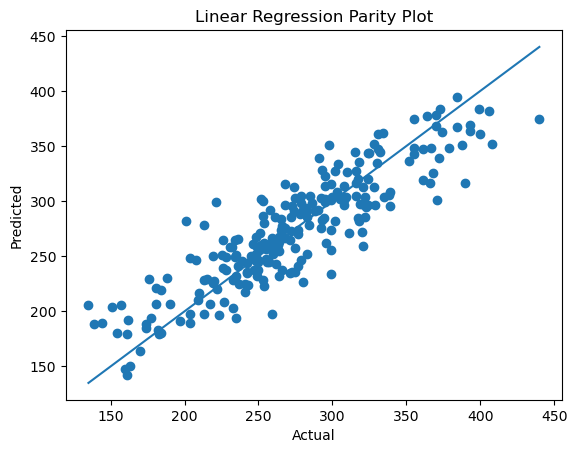

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Parity Plot")
plt.show()

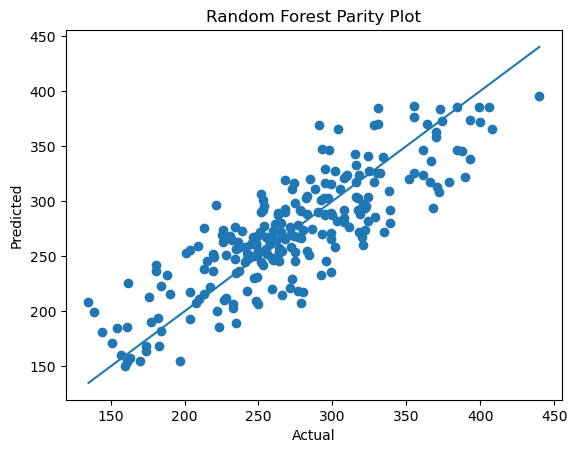

In [25]:
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Parity Plot")
plt.show()

The parity plots show that the Linear Regression model produces predictions that are more closely aligned with the actual values, as indicated by points clustering near the diagonal line.

In contrast, the Random Forest model exhibits greater dispersion, with predictions deviating more from the ideal diagonal line. This indicates higher prediction error and lower consistency.

These observations are consistent with the RMSE and MAE results, confirming that Linear Regression provides better predictive performance for this dataset.

In [27]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_pipeline.named_steps['model'].feature_importances_

feat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_importance.head(5)

,feature,importance
7,cat__store_size_small,0.184408
13,num__is_festival,0.174561
5,cat__location_type_urban,0.141088
11,num__day_of_week,0.100494
8,num__competition_density,0.067386


Feature importance analysis from the Random Forest model shows that store size, festival periods, and location type are the most influential factors affecting sales.

The most important feature is store_size_small, indicating that store size plays a significant role in determining the number of items sold. The is_festival feature also has high importance, highlighting the strong impact of seasonal events on sales.

Additionally, location_type_urban suggests that store location influences customer demand, while day_of_week captures weekly sales patterns. Competition_density also contributes, indicating that competitive environments affect store performance.

Overall, these results show that both operational factors (store size, location) and temporal factors (festivals, weekdays) are key drivers of sales.
    